In [19]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf
import torch.nn as nn
import sklearn.preprocessing
import torch.optim as optim
import talib as ta

**Extract Stock Data From Yfinance (Take Dummy Stock)**

In [20]:
user_in = input("What ticker would you like to use? (type 'd' for default)")
ticker = user_in.upper() if user_in != 'd' else 'AAPL'
data_df = yf.download(ticker, start="2022-1-1", end="2026-01-02")

[*********************100%***********************]  1 of 1 completed


In [21]:
data_df

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2022-01-03,178.103668,178.955006,173.895967,174.013387,104487900
2022-01-04,175.843216,179.013683,175.275662,178.710339,99310400
2022-01-05,171.165848,176.303172,170.891858,175.755193,94537600
2022-01-06,168.308472,171.537649,167.956198,168.993445,96904000
2022-01-07,168.474854,170.402574,167.359321,169.179402,86709100
...,...,...,...,...,...
2025-12-24,273.554016,275.172497,271.945536,272.085389,17910600
2025-12-26,273.144409,275.112569,272.604905,273.903708,21521800


**We will compare how engineered features including SMA, EMA, etc correlate**|

In [22]:
cols = ['SMA_20', 'EMA_10', 'RSI_14', 'ROC_10', 'VOL_20', 'VOLUME_20_D', 'SKEW_20', 'KURT_20']
df = pd.DataFrame(columns=cols)
data_df.columns = data_df.columns.get_level_values(0)

In [23]:
data_df

Price,Close,High,Low,Open,Volume
Date,,,,,
2022-01-03,178.103668,178.955006,173.895967,174.013387,104487900
2022-01-04,175.843216,179.013683,175.275662,178.710339,99310400
2022-01-05,171.165848,176.303172,170.891858,175.755193,94537600
2022-01-06,168.308472,171.537649,167.956198,168.993445,96904000
2022-01-07,168.474854,170.402574,167.359321,169.179402,86709100
...,...,...,...,...,...
2025-12-24,273.554016,275.172497,271.945536,272.085389,17910600
2025-12-26,273.144409,275.112569,272.604905,273.903708,21521800
2025-12-29,273.504089,274.103504,272.095404,272.435082,23715200


In [24]:
prices = data_df['Close'].values
df['SMA_20'] = prices / ta.SMA(prices, timeperiod=20)
df['EMA_10'] = prices / ta.EMA(prices, timeperiod=10)
df['RSI_14'] = ta.RSI(prices, timeperiod=14)
df['ROC_10'] = ta.ROC(prices, timeperiod=10)
df['VOL_20'] = ta.STDDEV(prices, timeperiod=20) / prices
avg_volume = ta.SMA(data_df['Volume'].values.astype(float), timeperiod=20)
df['VOLUME_20_D'] = data_df['Volume'].values.astype(float) / avg_volume
df['SKEW_20'] = data_df['Close'].rolling(window=20).skew().values.astype(float)
df['KURT_20'] = data_df['Close'].rolling(window=20).kurt().values.astype(float)

In [25]:
df

,SMA_20,EMA_10,RSI_14,ROC_10,VOL_20,VOLUME_20_D,SKEW_20,KURT_20
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
998,0.987942,0.999463,50.012072,-1.782771,0.015115,0.405481,0.465693,-0.362790
999,0.987201,0.998336,49.168915,-1.665288,0.015424,0.493893,0.562093,-0.436652
1000,0.989411,0.999714,49.966593,-1.624264,0.015516,0.542002,0.717140,-0.328885
1001,0.988743,0.997733,48.420933,-0.375756,0.014825,0.520535,0.979162,0.446620


<function matplotlib.pyplot.show(close=None, block=None)>

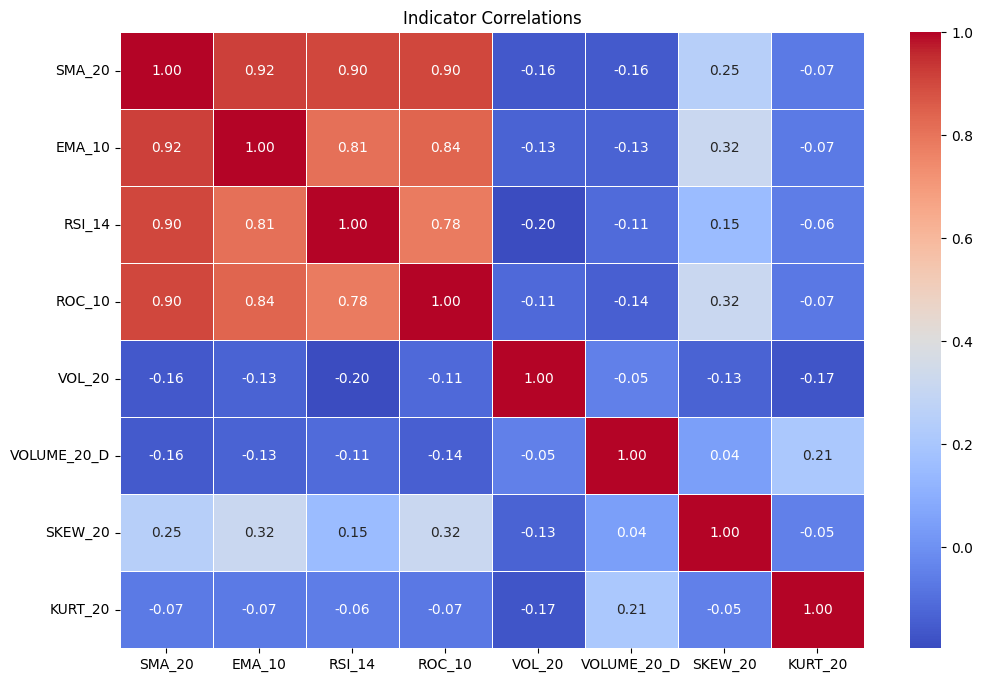

In [26]:
corr_mat = df.corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr_mat, annot=True, cmap='coolwarm', fmt= '.2f', linewidths=0.5)
plt.title('Indicator Correlations')
plt.show

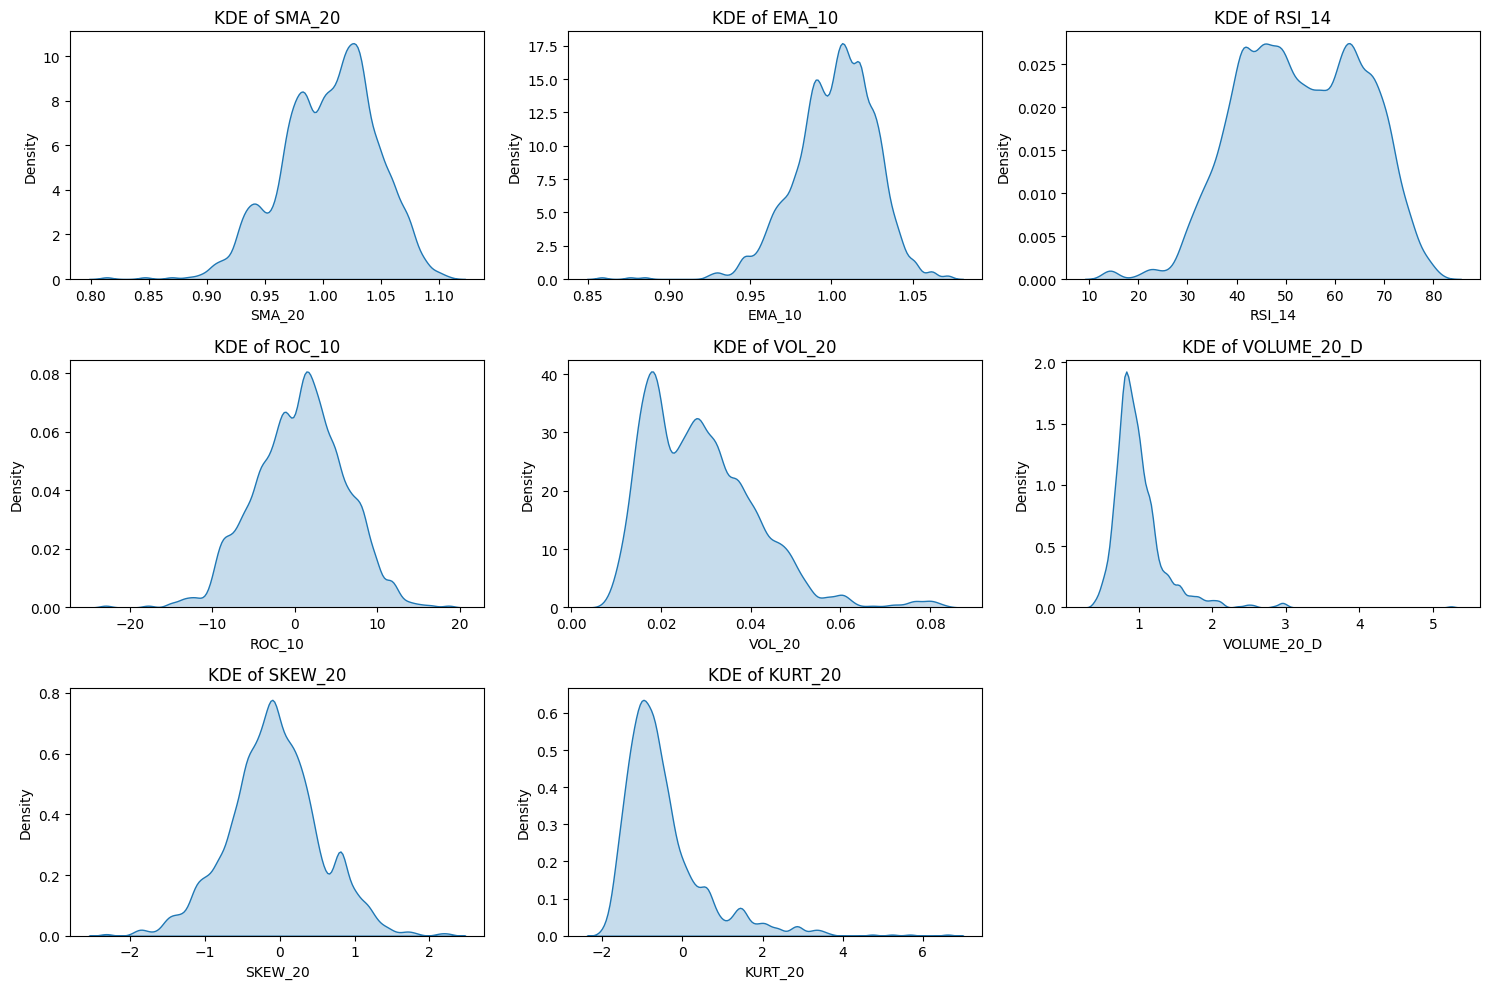

In [27]:
plot_cols = df.columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(plot_cols, 1):
    plt.subplot(3, 3, i)
    sns.kdeplot(df[col].dropna(), fill=True, bw_adjust=0.5)
    plt.title(f'KDE of {col}')

plt.tight_layout()
plt.show()